In [1]:
import pandas as pd
import numpy as np
import re

import torch
from torch import cuda
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# from transformers import TrainingArguments, Trainer
# from transformers import AutoTokenizer, AutoModel
from transformers import BertTokenizerFast
from transformers import BertForSequenceClassification

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')
device = 'cuda' if cuda.is_available() else 'cpu'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
tokenizer = BertTokenizerFast.from_pretrained("cointegrated/rubert-tiny")
model = BertForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny", num_labels=3
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider train

In [3]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

In [6]:
model.load_state_dict(torch.load("./models/model_rubert-tiny1.pt"))
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

Загрузка данных

In [7]:
df = pd.read_excel('./data/brent_march_2026.xls')

Предобработка данных

In [53]:
# Стемминг + стоп-слова
russian_stopwords = set(stopwords.words('russian'))
stemmer = SnowballStemmer("russian")

def preprocess_text(text):
    tokens = word_tokenize(text, language='russian')
    stems = []
    for token in tokens:
        if token.isalpha():
            stem = stemmer.stem(token.lower())
            if stem not in russian_stopwords:
                stems.append(stem)
    return ' '.join(stems)

df['text'] = df['text'].apply(preprocess_text)
df = df[df['text'].str.strip() != '']
print("Пример результата:")
print(df.head())
texts = df["text"].tolist()


def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return pred

Пример результата:
        date                                               text  prediction
0 2026-03-13  дефиц зажег огон паник помогл разгорет энергет...           1
1 2026-03-13  наст цел ир ядерн бомб ядерн программ ир удобн...           1
2 2026-03-13  кризис уб производств волн волн большинств смо...           0
3 2026-03-13  волн перв прям металл хим транспорт электродуг...           1
4 2026-03-13  волн трет месяц продовольств удар эт опасн нез...           0


In [52]:
df["prediction"] = df["text"].apply(predict)
print(df['prediction'].value_counts())


prediction
1    24
0    23
2     2
Name: count, dtype: int64


Подготовка и агрегация

In [36]:
df_base = df.copy()

def prepare_daily_counts(df):
    df = df.copy()

    # --- даты ---
    df["date"] = pd.to_datetime(df["date"]).dt.date

    # --- маппинг классов ---
    mapping = {
        0: "increase",
        1: "stable",
        2: "fall"
    }

    df["prediction"] = df["prediction"].map(mapping)

    # удаляем мусор
    df = df[df["prediction"].isin(["increase", "fall", "stable"])]

    # --- агрегация ---
    daily = (
        df.groupby(["date", "prediction"])
          .size()
          .unstack(fill_value=0)
    )

    daily = daily.reindex(columns=["increase", "fall", "stable"], fill_value=0)

    # --- сортировка ---
    daily = daily.sort_index()

    return daily

Микроциклы по 3 дня + формула

In [13]:
def compute_index(daily_df, window_size=3):
    results = []

    for i in range(len(daily_df) - window_size + 1):
        window = daily_df.iloc[i:i+window_size]

        increase_num = window["increase"].sum()
        fall_num = window["fall"].sum()
        stable_num = window["stable"].sum()

        summ = increase_num + fall_num + stable_num

        if summ == 0:
            continue

        # формула
        increase = summ * (increase_num / 100)
        fall = summ * (fall_num / 100)

        summ_trends = increase + fall

        if summ_trends == 0:
            increase_weight = 0.5
            fall_weight = 0.5
        else:
            increase_weight = increase / summ_trends
            fall_weight = fall / summ_trends

        index_value = (
            50
            + (increase_num + stable_num * increase_weight) * 0.5
            - (fall_num + stable_num * fall_weight) * 0.5
        )

        results.append({
            "start_date": window.index[0],
            "end_date": window.index[-1],
            "index": index_value
        })

    return pd.DataFrame(results)

Определение тренда

In [14]:
def detect_trend(df, threshold=0.5):
    df = df.copy()

    df["index_diff"] = df["index"].diff()

    def get_trend(x):
        if pd.isna(x):
            return None
        elif x > threshold:
            return "UP"
        elif x < -threshold:
            return "DOWN"
        else:
            return "FLAT"

    df["trend"] = df["index_diff"].apply(get_trend)

    return df

Финальный pipeline

In [15]:
def run_pipeline(df):
    # 1. агрегация
    daily = prepare_daily_counts(df)

    # 2. индекс (3-дневные микроциклы)
    index_df = compute_index(daily, window_size=3)

    # 3. тренд
    index_df = detect_trend(index_df)

    return index_df

In [51]:
result = run_pipeline(df_base)

print(result.head())


   start_date    end_date  index  index_diff trend
0  2026-03-02  2026-03-05  52.00         NaN  None
1  2026-03-04  2026-03-06  52.50        0.50  FLAT
2  2026-03-05  2026-03-09  53.50        1.00    UP
3  2026-03-06  2026-03-10  52.25       -1.25  DOWN
4  2026-03-09  2026-03-11  53.00        0.75    UP


Загрузка рыночных данных

In [17]:
import yfinance as yf

def load_brent(start, end):
    df = yf.download("BZ=F", start=start, end=end)

    df = df[["Close"]].rename(columns={"Close": "price"})
    df["return"] = df["price"].pct_change()

    return df

Совмещение с индексом

In [18]:
def merge_with_market(index_df, market_df):
    df = index_df.copy()

    df["date"] = pd.to_datetime(df["end_date"])
    df = df.set_index("date")

    merged = df.join(market_df, how="inner")

    return merged

функция прогноза на следующий микроцикл

In [19]:
def predict_next_cycle(index_df):
    """
    Предсказывает индекс на 1 микроцикл вперед (3 дня),
    используя разницу (diff) последних значений.
    """
    df = index_df.copy()

    # берем последний индекс
    last_index = df["index"].iloc[-1]

    # берем последнее изменение (diff)
    last_diff = df["index_diff"].iloc[-1] if "index_diff" in df.columns else df["index"].diff().iloc[-1]

    # прогноз на следующий микроцикл (1 лаг)
    predicted_index = last_index + last_diff

    return predicted_index

Генерация торговых сигналов

In [20]:
def generate_signals(df):
    df = df.copy()

    def signal_from_trend(trend):
        if trend == "UP":
            return 1   # long
        elif trend == "DOWN":
            return -1  # short
        else:
            return 0   # cash

    df["signal"] = df["trend"].apply(signal_from_trend)

    # лаг (ВАЖНО!)
    df["signal_shifted"] = df["signal"].shift(1)

    return df

Backtesting

In [21]:
import numpy as np

def backtest(df, cost=0.001):
    df = df.copy()

    # доход стратегии
    df["strategy_return"] = df["signal_shifted"] * df["return"]

    # транзакционные издержки
    df["trade"] = df["signal_shifted"].diff().abs()
    df["strategy_return"] -= df["trade"] * cost

    # накопленная доходность
    df["market"] = (1 + df["return"]).cumprod()
    df["strategy"] = (1 + df["strategy_return"]).cumprod()

    return df

Метрики

In [22]:
def compute_metrics(df):
    returns = df["strategy_return"].dropna()

    sharpe = returns.mean() / returns.std() * np.sqrt(252)

    cum = df["strategy"]
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()

    total_return = cum.iloc[-1] - 1

    return {
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Total Return": total_return
    }

Расчет индикатора следующего микроцикла (3 дня)

In [23]:
def predict_next_cycle(index_df, merged_df, threshold=0.5):
    # 1. последний индекс
    last_index = index_df["index"].iloc[-1]

    # 2. последняя разница
    last_diff = index_df["index_diff"].iloc[-1] if "index_diff" in index_df.columns else index_df["index"].diff().iloc[-1]

    # 3. предсказанный индекс
    predicted_index = last_index + last_diff

    # 4. прогнозный сигнал
    diff = predicted_index - last_index
    if diff > threshold:
        predicted_signal = 1
    elif diff < -threshold:
        predicted_signal = -1
    else:
        predicted_signal = 0

    # 5. прогнозное значение стратегии
    last_strategy = merged_df["strategy"].iloc[-1]
    last_return = merged_df["return"].iloc[-1]  # доходность последнего дня
    predicted_strategy = last_strategy * (1 + predicted_signal * last_return)

    return predicted_index, predicted_signal, predicted_strategy

In [24]:
# 1. Текущий pipeline
index_df = run_pipeline(df_base)

# 2. Рынок
market_df = load_brent(
    start=index_df["start_date"].min(),
    end=index_df["end_date"].max()
)
market_df.columns = [col[0] if isinstance(col, tuple) else col for col in market_df.columns]

# 3. Merge
merged = merge_with_market(index_df, market_df)

# 4. Сигналы и backtest
merged = generate_signals(merged)
merged = backtest(merged)

# 5. Прогноз следующего микроцикла
pred_index, next_signal, predicted_strategy_value = predict_next_cycle(index_df, merged)

print(f"Predicted index for next 3 days: {pred_index:.2f}")
print(f"Predicted strategy value for next 3 days: {predicted_strategy_value:.2f}")


/tmp/ipykernel_1765/836423503.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BZ=F", start=start, end=end)
[*********************100%***********************]  1 of 1 completed

Predicted index for next 3 days: 52.50
Predicted strategy value for next 3 days: 1.04


In [25]:
def plot_index_vs_price_with_prediction(index_df, merged_df, predicted_index):
    import matplotlib.pyplot as plt

    # --- подготовка index ---
    idx = index_df.copy()
    idx["date"] = pd.to_datetime(idx["end_date"])
    idx = idx.set_index("date")

    # --- merge с ценой ---
    df = idx.join(merged_df[["price"]], how="inner")

    # --- дата следующего микроцикла (+3 дня) ---
    next_date = df.index[-1] + pd.Timedelta(days=3)

    # --- график ---
    fig, ax1 = plt.subplots(figsize=(12,6))

    # INDEX (левая ось)
    ax1.plot(df.index, df["index"], color="blue", label="Index")

    # прогноз индикатора (опережение)
    ax1.scatter(next_date, predicted_index, color='red', s=100, label="Next cycle index")
    ax1.plot(
        [df.index[-1], next_date],
        [df["index"].iloc[-1], predicted_index],
        color='red',
        linestyle='--'
    )

    ax1.set_ylabel("Index", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")

    # Цена Brent (правая ось)
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["price"], color="orange", label="Brent Price")
    ax2.set_ylabel("Price", color="orange")
    ax2.tick_params(axis='y', labelcolor="orange")

    # легенда
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.title("Index vs Brent Price (with next cycle prediction)")
    plt.show()

Визуализация

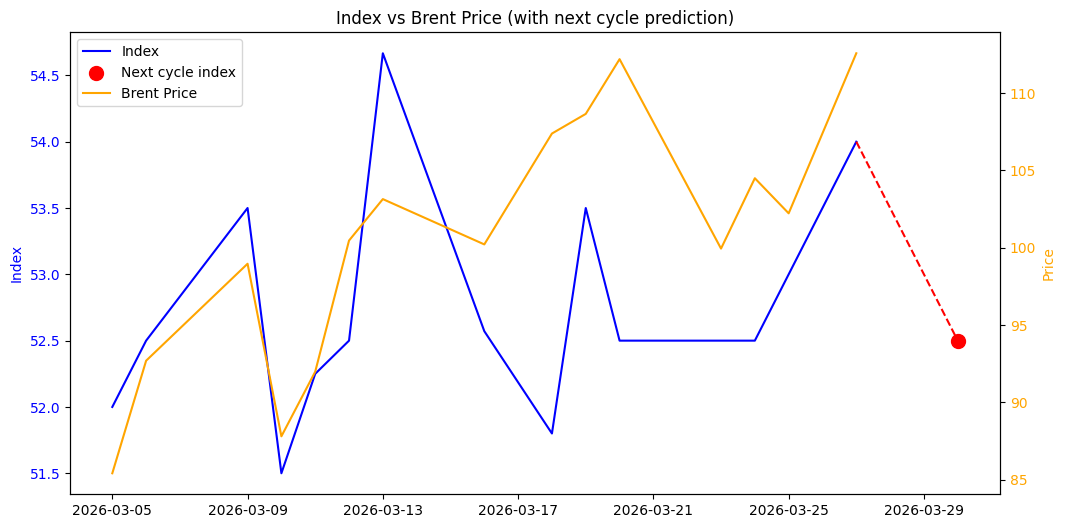

In [26]:
plot_index_vs_price_with_prediction(index_df, merged, pred_index)